In [1]:
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find the project root whether the notebook runs from notebooks/ or the root
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.metrics import mae, rmse
from src.models import make_models

HORIZON = 72
df = pd.read_csv(ROOT / "data" / "processed" / f"features_h{HORIZON}.csv",
                 index_col=0, parse_dates=True)
if df.index.tz is not None:
    df.index = df.index.tz_localize(None)

target = df.columns[-1]                      # last column is the price to predict
X_cols = list(df.columns[:-1])
BASE_COL = [c for c in X_cols if "168" in c and "lag" in c.lower()][0]   # price one week ago

print("target:", target, "| baseline column:", BASE_COL)
print(df.shape, df.index.min(), "to", df.index.max())

target: price_mwh | baseline column: price_lag_168
(15575, 19) 2024-12-15 01:00:00 to 2026-09-24 23:00:00


In [2]:
TEST_START = pd.Timestamp("2025-10-01")
BLOCK = pd.Timedelta(days=28)
GAP = pd.Timedelta(hours=HORIZON)

pieces, fold = [], 0
block_start = TEST_START
t0 = time.perf_counter()

while block_start <= df.index.max():
    block_end = block_start + BLOCK
    train = df[df.index <= block_start - GAP]                      # past only, with purge gap
    test = df[(df.index >= block_start) & (df.index < block_end)]  # next 28 days
    if len(test) == 0:
        break

    out = pd.DataFrame({"fold": fold, "actual": test[target], "baseline": test[BASE_COL]},
                       index=test.index)
    for name, model in make_models().items():                      # fresh models each fold
        model.fit(train[X_cols], train[target])
        out[name] = model.predict(test[X_cols])
    pieces.append(out)

    print(f"fold {fold:2d}: train {len(train):6d} rows, test {len(test):4d} rows "
          f"({block_start.date()} to {(test.index.max()).date()}), "
          f"{time.perf_counter() - t0:5.0f}s elapsed")
    fold += 1
    block_start = block_end

wf = pd.concat(pieces)
wf.to_csv(ROOT / "results" / f"walk_forward_h{HORIZON}.csv")
print("done:", wf.shape)

fold  0: train   6888 rows, test  672 rows (2025-10-01 to 2025-10-28),     3s elapsed
fold  1: train   7560 rows, test  672 rows (2025-10-29 to 2025-11-25),     6s elapsed
fold  2: train   8232 rows, test  672 rows (2025-11-26 to 2025-12-23),     9s elapsed
fold  3: train   8904 rows, test  672 rows (2025-12-24 to 2026-01-20),    12s elapsed
fold  4: train   9576 rows, test  672 rows (2026-01-21 to 2026-02-17),    15s elapsed
fold  5: train  10248 rows, test  672 rows (2026-02-18 to 2026-03-17),    18s elapsed
fold  6: train  10920 rows, test  672 rows (2026-03-18 to 2026-04-14),    22s elapsed
fold  7: train  11592 rows, test  672 rows (2026-04-15 to 2026-05-12),    26s elapsed
fold  8: train  12264 rows, test  672 rows (2026-05-13 to 2026-06-09),    31s elapsed
fold  9: train  12936 rows, test  672 rows (2026-06-10 to 2026-07-07),    36s elapsed
fold 10: train  13608 rows, test  672 rows (2026-07-08 to 2026-08-04),    42s elapsed
fold 11: train  14280 rows, test  672 rows (2026-08-05

In [3]:
assert wf.index.is_unique, "duplicate timestamps"
assert wf.index.is_monotonic_increasing, "out of order"
assert not wf.isna().any().any(), "missing values"
print("first/last test hour:", wf.index.min(), wf.index.max())
print("rows:", len(wf), "| folds:", wf["fold"].nunique())

first/last test hour: 2025-10-01 00:00:00 2026-09-24 23:00:00
rows: 8616 | folds: 13


                   MAE ($/MWh)  RMSE ($/MWh)
baseline                 53.78         91.00
Linear regression        45.04         69.43
Decision tree            43.31        115.69
SVR                      31.72         56.09


C:\Users\lithi\AppData\Local\Temp\ipykernel_25788\2929096149.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_fold = wf.groupby("fold").apply(lambda g: pd.Series({c: mae(g["actual"], g[c]) for c in cols}))


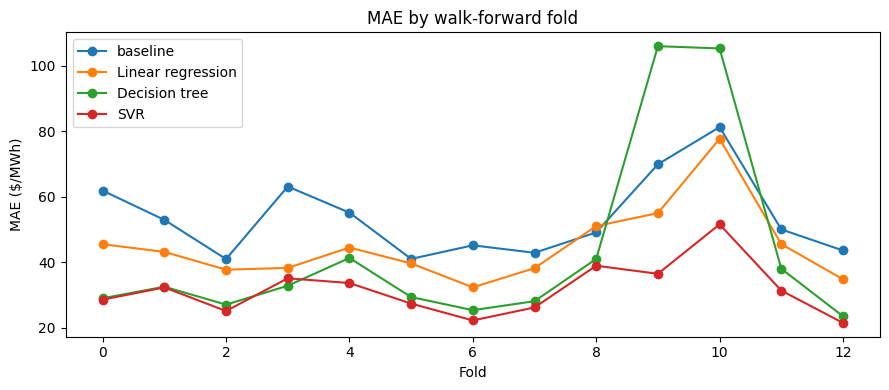

In [4]:
cols = ["baseline", "Linear regression", "Decision tree", "SVR"]
scores = pd.DataFrame({c: {"MAE ($/MWh)": mae(wf["actual"], wf[c]),
                           "RMSE ($/MWh)": rmse(wf["actual"], wf[c])} for c in cols}).T.round(2)
print(scores)

by_fold = wf.groupby("fold").apply(lambda g: pd.Series({c: mae(g["actual"], g[c]) for c in cols}))
by_fold.plot(marker="o", figsize=(9, 4), title="MAE by walk-forward fold")
plt.ylabel("MAE ($/MWh)"); plt.xlabel("Fold"); plt.tight_layout(); plt.show()